In [1]:
!pip install --upgrade pip
!pip install umap-learn hdbscan numba==0.60.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.9 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [2]:
import numpy as np
import pandas as pd
from scipy import sparse
import matplotlib.pyplot as plt
import umap
import hdbscan
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import trustworthiness
from sklearn.metrics import silhouette_score

FILE = "Merge_Completo_vigencia_total.parquet"
COL_ID   = "AFILIADO_ID_EPS"
COL_FINI = "FECHA_INICIO"
COL_FFIN = "FECHA_FIN"

dfa = pd.read_parquet(FILE)

dfa['FECHA_INICIO'] = pd.to_datetime(dfa['FECHA_INICIO'], errors='coerce')
dfa['FECHA_FIN']     = pd.to_datetime(dfa['FECHA_FIN'], errors='coerce')

# ---------------------------
# Meses transcurridos
# ---------------------------

meses = (dfa['FECHA_FIN'].dt.year - dfa['FECHA_INICIO'].dt.year) * 12 + \
        (dfa['FECHA_FIN'].dt.month - dfa['FECHA_INICIO'].dt.month)

ajuste_mes = (dfa['FECHA_FIN'].dt.day < dfa['FECHA_INICIO'].dt.day).astype(int)

dfa['meses_transcurridos'] = meses - ajuste_mes

dfa['meses_transcurridos'] = dfa['meses_transcurridos'].clip(lower=0)

# ---------------------------
# Para Excluir FALLA_BIN==0 y meses<12
# ---------------------------
cond_excluir = (dfa['FALLA_BIN'] == 0) & (dfa['meses_transcurridos'] < 12)
df_filtrado = dfa.loc[~cond_excluir].copy()

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [3]:
def build_X_sparse(df_in, drop_cancel_cols=False):
    df = df_in.copy()

    cat_code_cols = ["CONDICION_SALUD", "NIVEL_INGRESO", "PLAN"]
    cat_code_cols = [c for c in cat_code_cols if c in df.columns]

    for c in cat_code_cols:
        df[c] = df[c].astype("category")

    df_cat = pd.get_dummies(df[cat_code_cols], prefix=cat_code_cols, dtype=int)

    dummy_cols_bin = [
        "Sexo_Cd_BIN","POLIZA_BIN","MARCA_CAC_BIN",
        "SEGMENTO_EDAD_01_DEPENDIENTE","SEGMENTO_EDAD_02_ADULTOJOVEN",
        "SEGMENTO_EDAD_03_PRODUCTIVO","SEGMENTO_EDAD_04_ADULTOMAYOR",
        "TIPO_AFILIADO_ASEGURADO COLECTIVO","TIPO_AFILIADO_ASEGURADO FAMILIAR",
        "TIPO_AFILIADO_TOMADOR FAMILIAR",
        "Regional_Agrupadora_CENTRO","Regional_Agrupadora_NORTE",
        "Regional_Agrupadora_OCCIDENTE","Regional_Agrupadora_ORIENTE",
        "Regional_Agrupadora_SUR",
        "GRUPO_CAUSA_CANCELACION_MORA","GRUPO_CAUSA_CANCELACION_NO APLICA",
        "GRUPO_CAUSA_CANCELACION_NO PBS","GRUPO_CAUSA_CANCELACION_OTRAS CAUSAS",
        "GRUPO_CAUSA_CANCELACION_PETICION DEL CLIENTE",
        "Compania_DIGITAL","Compania_PROPIO","Compania_TERCERO",
        "RAMO_FAMILIAR",
        "TIPO_IPS_ALIADA","TIPO_IPS_CONVENIO","TIPO_IPS_EXCLUSIVA",
        "TIPO_IPS_PROPIA","TIPO_IPS_SIN INFORMACION"
    ]
    dummy_cols_bin = [c for c in dummy_cols_bin if c in df.columns]

    if drop_cancel_cols:
        dummy_cols_bin = [c for c in dummy_cols_bin if not c.startswith("GRUPO_CAUSA_CANCELACION_")]

    df_dummy_bin = df[dummy_cols_bin].fillna(0).astype(int)


    num_cols = [
        "Prestaciones_PAC","Prestaciones_PBS","Prestaciones_PAC_FIN","Prestaciones_PBS_FIN",
        "Felicitaciones_PAC","Felicitaciones_PBS","Felicitaciones_PAC_FIN","Felicitaciones_PBS_FIN",
        "Inquietud_PAC","Inquietud_PBS","Inquietud_PAC_FIN","Inquietud_PBS_FIN",
        "Peticion_PAC","Peticion_PBS","Peticion_PAC_FIN","Peticion_PBS_FIN",
        "Queja_PAC","Queja_PBS","Queja_PAC_FIN","Queja_PBS_FIN",
        "Sugerencia_PAC","Sugerencia_PBS","Sugerencia_PAC_FIN","Sugerencia_PBS_FIN",
        "meses_transcurridos"
    ]
    num_cols = [c for c in num_cols if c in df.columns]

    X_num = df[num_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

    totales_cols = [c for c in num_cols if c not in ["meses_transcurridos"]]
    X_num[totales_cols] = X_num[totales_cols].clip(lower=0)
    X_num[totales_cols] = np.log1p(X_num[totales_cols])
    X_num = X_num.replace([np.inf, -np.inf], np.nan).fillna(0)

    scaler = StandardScaler(with_mean=False)
    X_num_std = scaler.fit_transform(X_num.values)
    X_num_std = scaler.fit_transform(X_num)
    X_cat_std = scaler.fit_transform(df_cat)
    X_dummy_std = scaler.fit_transform(df_dummy_bin)

    # sparse
    X_num_sp   = sparse.csr_matrix(X_num_std)
    X_cat_sp   = sparse.csr_matrix(X_cat_std)
    X_dummy_sp = sparse.csr_matrix(X_dummy_std)

    X_sparse = sparse.hstack([X_num_sp, X_cat_sp, X_dummy_sp], format="csr")

    return X_sparse, num_cols, cat_code_cols, dummy_cols_bin


In [4]:
import numpy as np
import pandas as pd
import umap
import hdbscan
import matplotlib.pyplot as plt
from sklearn.manifold import trustworthiness
from sklearn.metrics import silhouette_score

def score_hdbscan_scaled_7000(emb, labels, clusterer, *,
                              use_silhouette=True,
                              alpha=0.4,        # penalización por ruido
                              gamma=1.0,        # convexidad del ruido
                              beta=0.8,         # penalización por K
                              scale_mode='sqrtN',  # 'sqrtN' | 'logN' | 'none'
                              delta=0.06,       # bonificación por membresía firme
                              prob_threshold=0.7,
                              min_points_for_sil=10):
    """
    Score compuesto para UMAP + HDBSCAN con N ~ 7000 y n_components=5.
    Score = B - α·r^γ - β·(K / S(N)) + δ·(p_high - 0.5)
    """
    labels = np.asarray(labels)
    N = len(labels)
    noise_mask = labels == -1
    r = float(np.mean(noise_mask))

    unique = set(labels)
    K = len(unique) - (1 if -1 in unique else 0)
    if K <= 1:
        return -1e9, {"B": None, "r": r, "K": K, "p_high": None, "N": N}

    # Base B
    B = None
    sil = None
    try:
        from hdbscan.validity import validity_index
        B = float(validity_index(emb, labels))
    except Exception:
        B = float(getattr(clusterer, "relative_validity_", 0.0))
        if use_silhouette:
            mask = ~noise_mask
            lbls_masked = labels[mask]
            if mask.sum() >= min_points_for_sil and len(set(lbls_masked)) > 1:
                try:
                    sil = float(silhouette_score(emb[mask], lbls_masked))
                    B = 0.7 * B + 0.3 * sil
                except Exception:
                    sil = None

    # Escalado S(N)
    if scale_mode == 'sqrtN' and N > 0:
        S = np.sqrt(N)
    elif scale_mode == 'logN' and N > 1:
        S = np.log(N)
    else:
        S = 1.0

    # Probabilidades de membresía
    p_high = None
    try:
        probs = np.asarray(getattr(clusterer, "probabilities_", None))
        if probs is not None and len(probs) == N:
            p_high = float(np.mean(probs[~noise_mask] >= prob_threshold))
    except Exception:
        p_high = None

    pen_noise = alpha * (r ** gamma)
    pen_K = beta * (K / S)
    bonus_p = delta * ((p_high - 0.5) if p_high is not None else 0.0)

    score = float(B - pen_noise - pen_K + bonus_p)
    details = {
        "B": B,
        "silhouette": sil,
        "r": r,
        "pen_noise": pen_noise,
        "K": K,
        "pen_K": pen_K,
        "p_high": p_high,
        "bonus_p": bonus_p,
        "N": N,
        "S(N)": S,
        "params": {"alpha": alpha, "gamma": gamma, "beta": beta, "delta": delta, "prob_threshold": prob_threshold}
    }
    return score, details


def run_umap_hdbscan_group(df_group, group_name="grupo", target_sample=7000,
                           neighbors_grid=[15,30,50,75,100],
                           mindist_grid=[0.01,0.05,0.1],
                           ms_grid=[30,50,75],
                           mcs_grid=[50,100,150,200],
                           drop_cancel_cols=False):

    df_group = df_group.copy().reset_index(drop=True)

    X_sparse, num_cols, cat_cols, dummy_cols = build_X_sparse(
        df_group, drop_cancel_cols=drop_cancel_cols
    )
    n = len(df_group)

    rng = np.random.RandomState(42)
    if n > target_sample:
        subset_pos = rng.choice(n, size=target_sample, replace=False)
    else:
        subset_pos = np.arange(n)

    X_sub = X_sparse[subset_pos]

    # Busca mejores UMAP por trustworthiness
    umap_candidates = []
    for nn in neighbors_grid:
        for md in mindist_grid:
            reducer = umap.UMAP(
                n_neighbors=nn, min_dist=md, n_components=10,
                metric="cosine", random_state=42,
                low_memory=True, n_jobs=-1
            )
            emb2 = reducer.fit_transform(X_sub)
            tw = trustworthiness(X_sub, emb2, n_neighbors=min(15, nn))
            umap_candidates.append({"nn": nn, "md": md, "trust": tw})

    umap_df = pd.DataFrame(umap_candidates).sort_values("trust", ascending=False)
    top_umap = umap_df.head(3).to_dict("records")

    results = []
    best_payload = None
    best_score = -np.inf

    for cand in top_umap:
        nn, md, tw = cand["nn"], cand["md"], cand["trust"]

        reducer = umap.UMAP(
            n_neighbors=nn, min_dist=md, n_components=10,
            metric="cosine", random_state=42,
            low_memory=True, n_jobs=-1
        )
        emb2 = reducer.fit_transform(X_sub)

        for ms in ms_grid:
            for mcs in mcs_grid:
                hd = hdbscan.HDBSCAN(
                    min_samples=ms,
                    min_cluster_size=mcs,
                    metric="euclidean",
                    prediction_data=True
                )
                labels = hd.fit_predict(emb2)

                K = len(set(labels)) - (1 if -1 in labels else 0)
                noise = float(np.mean(labels == -1))

                # Usar el score compuesto con detalles
                sc, det = score_hdbscan_scaled_7000(
                    emb=emb2,
                    labels=labels,
                    clusterer=hd,
                    alpha=0.4,
                    gamma=1.0,
                    beta=0.8,
                    scale_mode='sqrtN',
                    delta=0.06,
                    prob_threshold=0.7
                )

                row = {
                    "nn": nn, "md": md, "trust": tw,
                    "min_samples": ms, "min_cluster_size": mcs,
                    "K": K, "noise_frac": noise, "score": sc,
                    # detalles del score
                    "base_B": det.get("B", None),
                    "silhouette_nr": det.get("silhouette", None),
                    "pen_noise": det.get("pen_noise", None),
                    "pen_K": det.get("pen_K", None),
                    "p_high": det.get("p_high", None),
                    "N_eval": det.get("N", None),
                    "Sn_eval": det.get("S(N)", None)
                }
                results.append(row)

                if sc > best_score:
                    best_score = sc
                    best_payload = {
                        **row,     # métricas
                        "emb": emb2,
                        "labels": labels,
                        "clusterer": hd
                    }

    res_df = pd.DataFrame(results).sort_values("score", ascending=False)

    # El mejor candidato con detalles incluidos
    best = res_df.iloc[0].to_dict()
    if best_payload is not None:
        # asegura que best contenga emb, labels, clusterer por si luego los quieres usar
        best["emb"] = best_payload["emb"]
        best["labels"] = best_payload["labels"]
        best["clusterer"] = best_payload["clusterer"]

    # Entrenar el mejor en muestra y aplicar a full datos
    NN_ELEGIDO  = int(best["nn"])
    MD_ELEGIDO  = float(best["md"])
    MS_ELEGIDO  = int(best["min_samples"])
    MCS_ELEGIDO = int(best["min_cluster_size"])

    umap_best = umap.UMAP(
        n_neighbors=NN_ELEGIDO, min_dist=MD_ELEGIDO, n_components=10,
        metric="cosine", random_state=42,
        low_memory=True, n_jobs=-1
    )

    Z2_sub  = umap_best.fit_transform(X_sub)
    Z2_full = umap_best.transform(X_sparse)

    hd_final = hdbscan.HDBSCAN(
        min_samples=MS_ELEGIDO,
        min_cluster_size=MCS_ELEGIDO,
        metric="euclidean",
        prediction_data=True
    )
    hd_final.fit(Z2_sub)

    labels_full, probs_full = hdbscan.approximate_predict(hd_final, Z2_full)

    df_group["cluster"] = labels_full
    df_group["prob_cluster"] = probs_full
    df_group["outlier"] = (labels_full == -1).astype(int)
    df_group["grupo_churn"] = group_name


    labels_sub = hd_final.labels_
    unique_labels = np.unique(labels_sub)

    from mpl_toolkits.mplot3d import Axes3D

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection='3d')

    for lab in unique_labels:
      mask = (labels_sub == lab)
      nombre = "Outliers" if lab == -1 else f"Cluster {lab}"
      ax.scatter(
          Z2_sub[mask, 0],  # UMAP-1
          Z2_sub[mask, 1],  # UMAP-2
          Z2_sub[mask, 2],  # UMAP-3
          s=8,
          alpha=0.7,
          label=nombre
      )

    ax.set_title(
        f"{group_name}: mejor UMAP+HDBSCAN (3D)\n"
        f"nn={NN_ELEGIDO}, md={MD_ELEGIDO}, "
        f"ms={MS_ELEGIDO}, mcs={MCS_ELEGIDO}"
    )
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.set_zlabel("UMAP-3")
    plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


    print(f"\n{group_name} | mejor config:", {k: best[k] for k in [
        "nn","md","trust","min_samples","min_cluster_size","K","noise_frac","score"
    ]})
    print(f"{group_name} | detalles score:", {k: best.get(k, None) for k in [
        "base_B","silhouette_nr","pen_noise","pen_K","p_high","N_eval","Sn_eval"
    ]})
    print(f"{group_name} | clusters:",
          df_group["cluster"].value_counts(dropna=False).head(10))

    return df_group, best, umap_df, res_df


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr

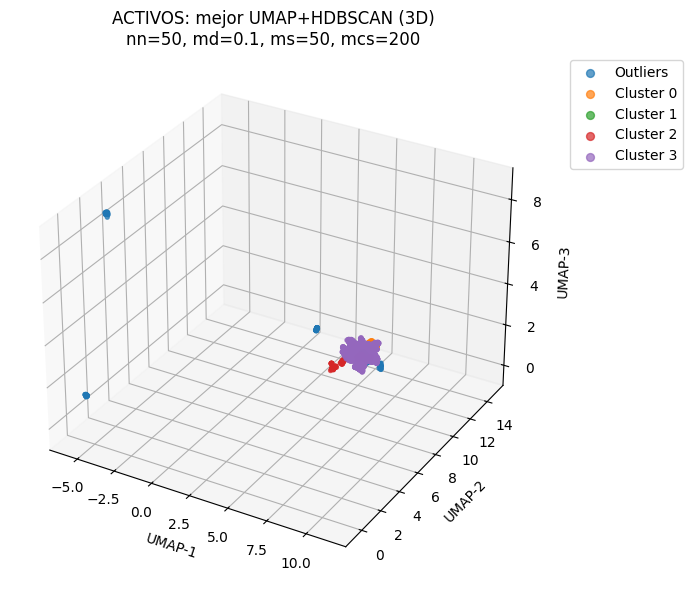


ACTIVOS | mejor config: {'nn': 50.0, 'md': 0.1, 'trust': 0.9847119255786018, 'min_samples': 50.0, 'min_cluster_size': 200.0, 'K': 4.0, 'noise_frac': 0.05057142857142857, 'score': 0.15072876079386155}
ACTIVOS | detalles score: {'base_B': 0.18258111476898192, 'silhouette_nr': 0.6086037158966064, 'pen_noise': 0.02022857142857143, 'pen_K': 0.0382473154987006, 'p_high': 0.9437255492025278, 'N_eval': 7000.0, 'Sn_eval': 83.66600265340756}
ACTIVOS | clusters: cluster
 3    161054
 2     17146
 0     14858
-1      8033
 1      7170
Name: count, dtype: int64

Resultados para el grupo: ACTIVOS
Mejor configuración encontrada:
 - n_neighbors (UMAP): 50.0
 - min_dist (UMAP): 0.1
 - Trustworthiness: 0.9847
 - min_samples (HDBSCAN): 50.0
 - min_cluster_size (HDBSCAN): 200.0
 - Num de clusters (K): 4.0
 - Fracción de noise: 5.0571%
 - Score combinado: 0.1507
Desglose del score:
   · Base (DBCV o mezcla): 0.1826
   · Silhouette no ruido: 0.6086
   · Proporción p_high ≥ 0.7: 94.3726%
   · Penalización r

168777

In [5]:

import gc

df_activos = df_filtrado[df_filtrado["FALLA_BIN"] == 0].copy()
activos_seg, best_act, umap_act, sweep_act = run_umap_hdbscan_group(
    df_activos,
    group_name="ACTIVOS",
    target_sample=7000,
    drop_cancel_cols=True
)

print("\n==============================================")
print(f"Resultados para el grupo: ACTIVOS")
print("==============================================")
print("Mejor configuración encontrada:")
print(f" - n_neighbors (UMAP): {best_act['nn']}")
print(f" - min_dist (UMAP): {best_act['md']}")
print(f" - Trustworthiness: {best_act['trust']:.4f}")
print(f" - min_samples (HDBSCAN): {best_act['min_samples']}")
print(f" - min_cluster_size (HDBSCAN): {best_act['min_cluster_size']}")
print(f" - Num de clusters (K): {best_act['K']}")
print(f" - Fracción de noise: {best_act['noise_frac']:.4%}")
print(f" - Score combinado: {best_act['score']:.4f}")
# Desglose del score
if 'base_B' in best_act:
    print("Desglose del score:")
    if isinstance(best_act.get('base_B', None), (int, float)):
        print(f"   · Base (DBCV o mezcla): {best_act['base_B']:.4f}")
    if isinstance(best_act.get('silhouette_nr', None), (int, float)):
        print(f"   · Silhouette no ruido: {best_act['silhouette_nr']:.4f}")
    if isinstance(best_act.get('p_high', None), (int, float)):
        print(f"   · Proporción p_high ≥ 0.7: {best_act['p_high']:.4%}")
    if isinstance(best_act.get('pen_noise', None), (int, float)):
        print(f"   · Penalización ruido: {best_act['pen_noise']:.4f}")
    if isinstance(best_act.get('pen_K', None), (int, float)):
        print(f"   · Penalización K: {best_act['pen_K']:.4f}")
print("==============================================\n")

print("Distribución de clusters en ACTIVOS:")
print(activos_seg['cluster'].value_counts(dropna=False))

del df_activos, umap_act, sweep_act
gc.collect()


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr

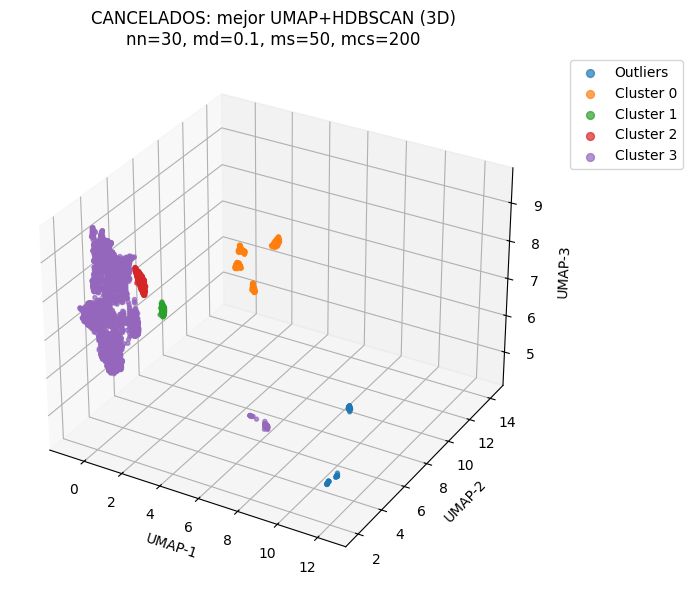


CANCELADOS | mejor config: {'nn': 30.0, 'md': 0.1, 'trust': 0.9780941392466403, 'min_samples': 50.0, 'min_cluster_size': 200.0, 'K': 4.0, 'noise_frac': 0.017, 'score': 0.18247740294317735}
CANCELADOS | detalles score: {'base_B': 0.19853619933128355, 'silhouette_nr': 0.6617873311042786, 'pen_noise': 0.0068000000000000005, 'pen_K': 0.0382473154987006, 'p_high': 0.9831419851765731, 'N_eval': 7000.0, 'Sn_eval': 83.66600265340756}
CANCELADOS | clusters: cluster
 3    132210
 0     13556
 2     13533
 1      5550
-1      2129
Name: count, dtype: int64

Resultados para el grupo: CANCELADOS
Mejor configuración encontrada:
 - n_neighbors (UMAP): 30.0
 - min_dist (UMAP): 0.1
 - Trustworthiness: 0.9781
 - min_samples (HDBSCAN): 50.0
 - min_cluster_size (HDBSCAN): 200.0
 - Num de clusters (K): 4.0
 - Fracción de noise: 1.7000%
 - Score combinado: 0.1825
Desglose del score:
   · Base (DBCV o mezcla): 0.1985
   · Silhouette no ruido: 0.6618
   · Proporción p_high ≥ 0.7: 98.3142%
   · Penalización r

In [6]:
import gc

# Filtrado y ejecución para CANCELADOS
df_cancelados = df_filtrado[df_filtrado["FALLA_BIN"] == 1].copy()
cancel_seg, best_can, umap_can, sweep_can = run_umap_hdbscan_group(
    df_cancelados,
    group_name="CANCELADOS",
    target_sample=7000,
    drop_cancel_cols=False
)

# Datos CANCELADOS
print("\n==============================================")
print("Resultados para el grupo: CANCELADOS")
print("==============================================")
print("Mejor configuración encontrada:")
print(f" - n_neighbors (UMAP): {best_can['nn']}")
print(f" - min_dist (UMAP): {best_can['md']}")
print(f" - Trustworthiness: {best_can['trust']:.4f}")
print(f" - min_samples (HDBSCAN): {best_can['min_samples']}")
print(f" - min_cluster_size (HDBSCAN): {best_can['min_cluster_size']}")
print(f" - Num de clusters (K): {best_can['K']}")
print(f" - Fracción de noise: {best_can['noise_frac']:.4%}")
print(f" - Score combinado: {best_can['score']:.4f}")

# Desglose del score compuesto si está disponible
if 'base_B' in best_can:
    print("Desglose del score:")
    if isinstance(best_can.get('base_B', None), (int, float)):
        print(f"   · Base (DBCV o mezcla): {best_can['base_B']:.4f}")
    if isinstance(best_can.get('silhouette_nr', None), (int, float)):
        print(f"   · Silhouette no ruido: {best_can['silhouette_nr']:.4f}")
    if isinstance(best_can.get('p_high', None), (int, float)):
        print(f"   · Proporción p_high ≥ 0.7: {best_can['p_high']:.4%}")
    if isinstance(best_can.get('pen_noise', None), (int, float)):
        print(f"   · Penalización ruido: {best_can['pen_noise']:.4f}")
    if isinstance(best_can.get('pen_K', None), (int, float)):
        print(f"   · Penalización K: {best_can['pen_K']:.4f}")

print("==============================================\n")

# Distribución de clusters en CANCELADOS
print("Distribución de clusters en CANCELADOS:")
print(cancel_seg['cluster'].value_counts(dropna=False))

# Limpieza
del df_cancelados, umap_can, sweep_can
gc.collect()

# Concatenación final con ACTIVOS
df_final = pd.concat([activos_seg, cancel_seg], axis=0).reset_index(drop=True)


In [7]:

import gc
import numpy as np
import matplotlib.pyplot as plt
import umap
from sklearn.manifold import trustworthiness

def plot_umap_grid_group(df_group, group_name="grupo",
                         target_sample=7000,
                         neighbors_grid=[15, 30, 50, 75, 100],
                         mindist_grid=[0.01, 0.05, 0.1],
                         drop_cancel_cols=False,
                         n_components_umap=2,
                         umap_metric="cosine"):
    """
    Visualiza UMAP en rejilla (n_neighbors x min_dist) para un grupo.
    - Submuestrea hasta target_sample para estabilidad.
    - Calcula trustworthiness por panel.
    - Muestra las dos primeras dimensiones del embebido, aunque sea de 5D.

    Params:
      n_components_umap: dimensiones del embebido UMAP (recomendado 5 para calidad).
      umap_metric: 'cosine' suele ser más estable con matrices sparse de mezcla num+dummy.
    """
    df_g = df_group.copy().reset_index(drop=True)

    # Construir matriz sparse
    X_sparse, num_cols, cat_cols, dummy_cols = build_X_sparse(
        df_g, drop_cancel_cols=drop_cancel_cols
    )
    n = X_sparse.shape[0]

    # Submuestreo reproducible
    rng = np.random.RandomState(42)
    if n > target_sample:
        subset_pos = rng.choice(n, size=target_sample, replace=False)
    else:
        subset_pos = np.arange(n)

    X_sub = X_sparse[subset_pos]

    # Crear rejilla de subplots con manejo de casos 1xN o Nx1
    n_rows = len(neighbors_grid)
    n_cols = len(mindist_grid)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2*n_cols + 1, 2.8*n_rows + 1))
    fig.suptitle(f"Exploración UMAP - {group_name}", y=0.98)

    # Normaliza axes a un array 2D
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = np.array([axes])
    elif n_cols == 1:
        axes = np.array([[ax] for ax in axes])

    for i, nn in enumerate(neighbors_grid):
        for j, md in enumerate(mindist_grid):
            ax = axes[i, j]
            try:
                reducer = umap.UMAP(
                    n_neighbors=nn,
                    min_dist=md,
                    n_components=n_components_umap,
                    metric=umap_metric,
                    random_state=42,
                    low_memory=True,
                    n_jobs=-1
                )
                emb = reducer.fit_transform(X_sub)

                # Trustworthiness con k razonable según nn
                tw_k = min(15, nn)
                tw = trustworthiness(X_sub, emb, n_neighbors=tw_k)

                # Mostrar primeras dos dimensiones, aun si n_components=5
                ax.scatter(emb[:, 0], emb[:, 1], s=2, alpha=0.6)
                ax.set_title(f"nn={nn}, md={md}\ntrust={tw:.3f}", fontsize=9)
            except Exception as e:
                ax.text(0.5, 0.5, f"Error\nnn={nn}, md={md}\n{str(e)}",
                        ha="center", va="center", fontsize=9)
                ax.set_title(f"nn={nn}, md={md}\nfalló", fontsize=9)

            ax.set_xticks([])
            ax.set_yticks([])

            # liberar embebido si te preocupa memoria
            try:
                del emb
            except:
                pass

    plt.tight_layout()
    plt.show()
    # Limpieza opcional
    gc.collect()



/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr

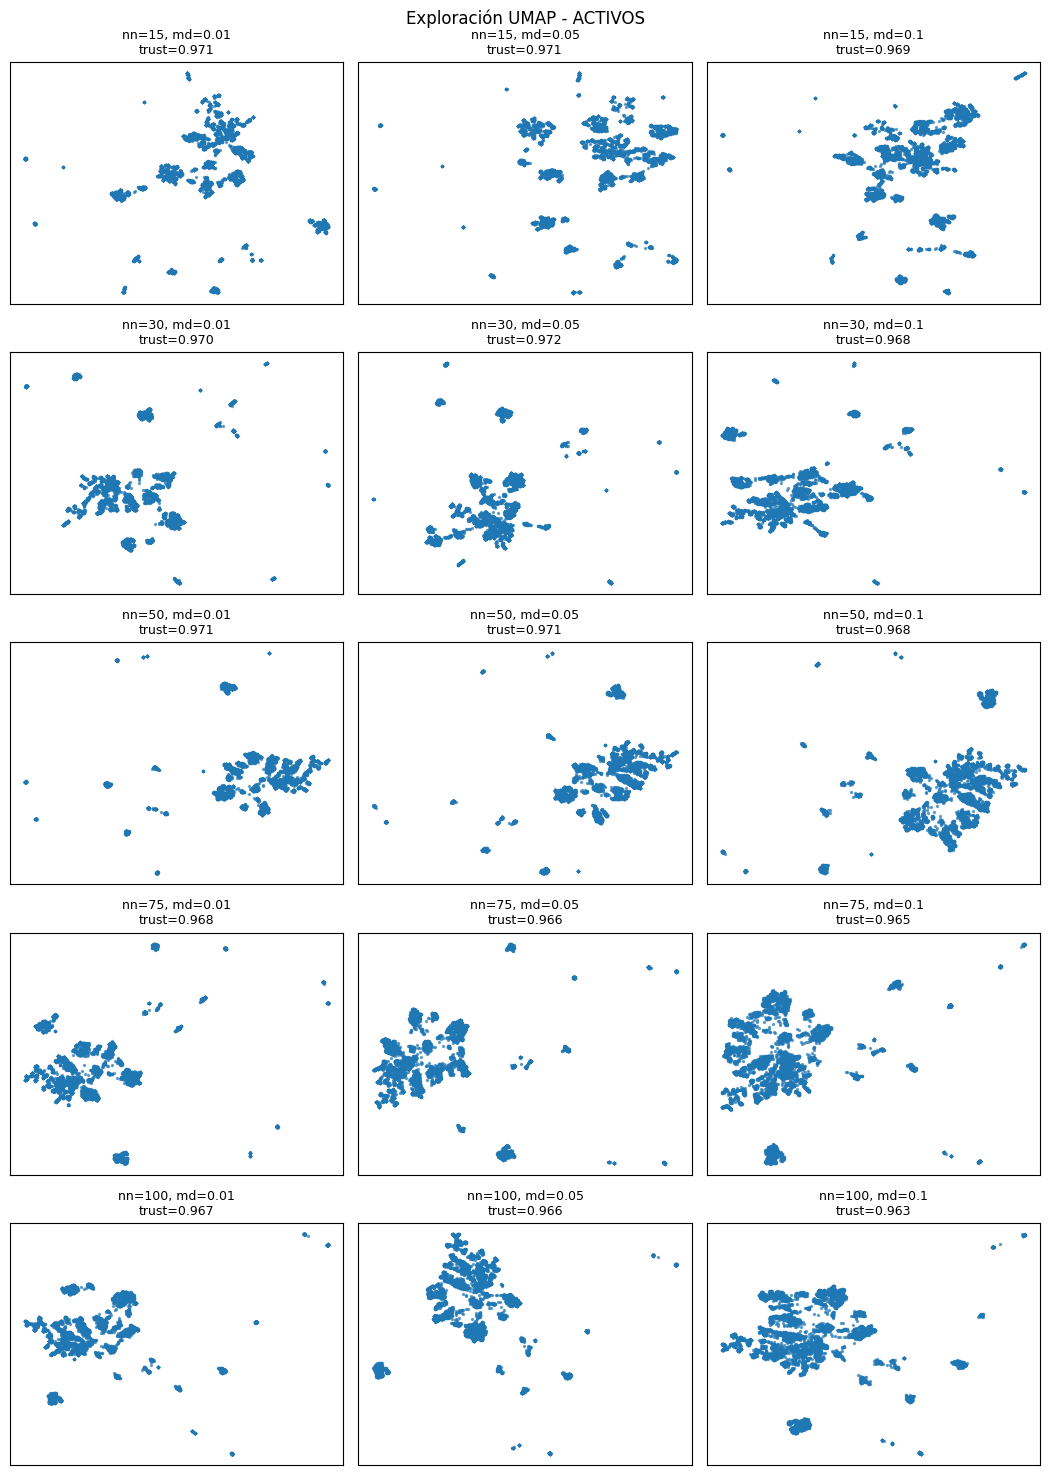

In [9]:
df_activos = df_filtrado[df_filtrado["FALLA_BIN"] == 0].copy()
plot_umap_grid_group(
    df_activos,
    group_name="ACTIVOS",
    target_sample=7000,
    neighbors_grid=[15,30,50,75,100],
    mindist_grid=[0.01, 0.05, 0.1],
    drop_cancel_cols=True
)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr

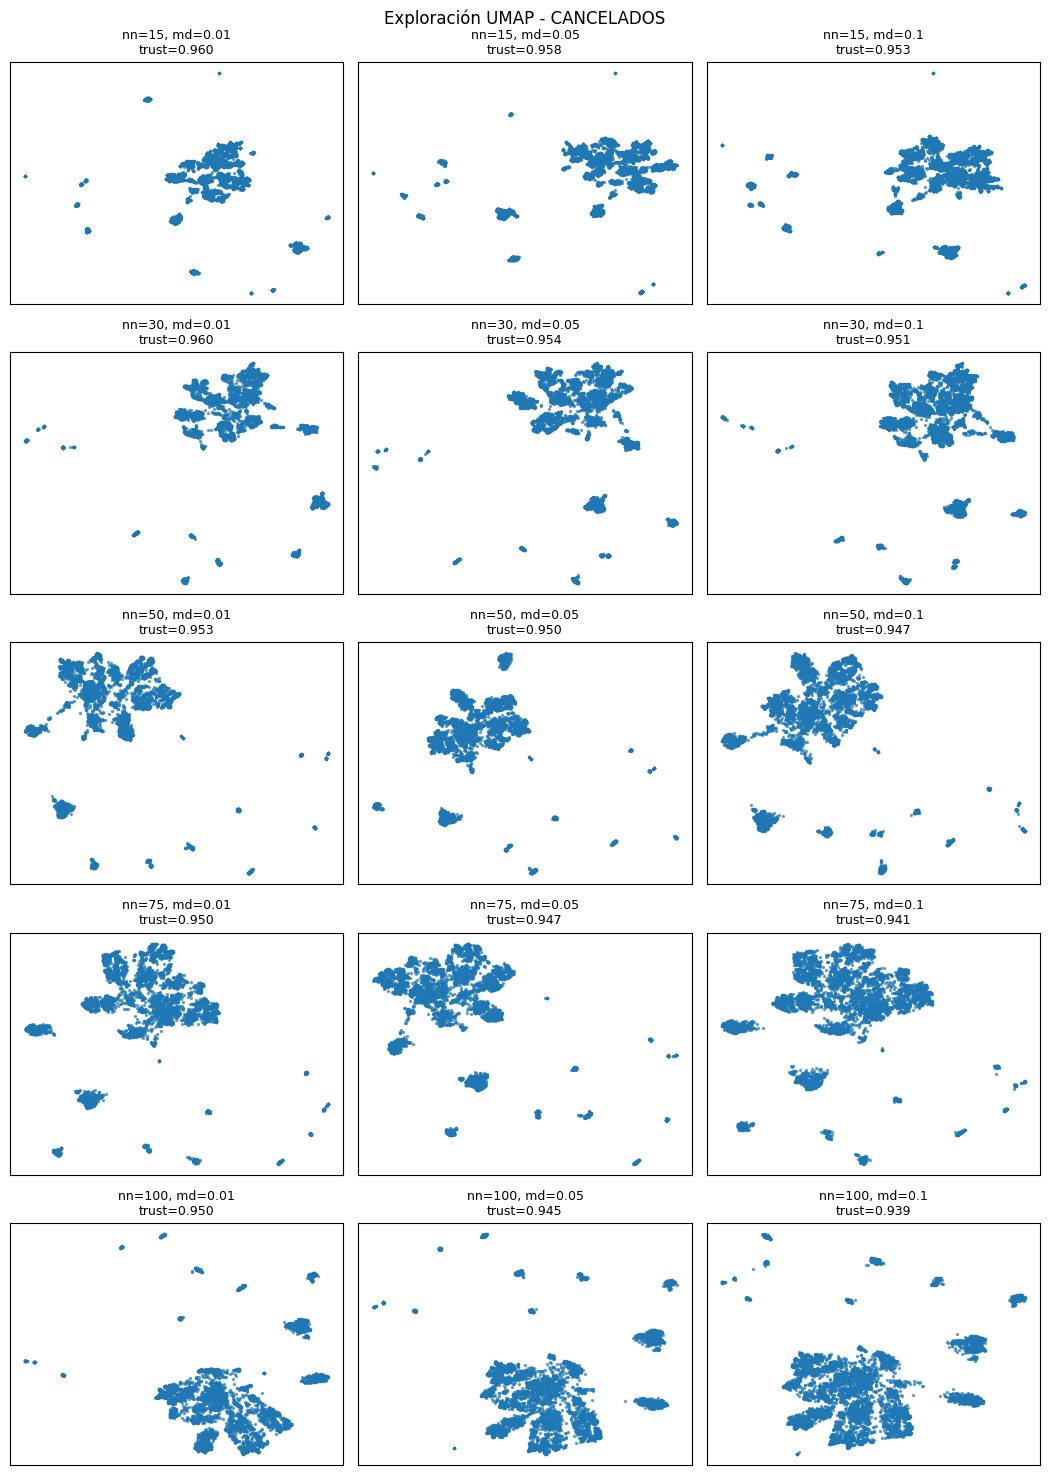

In [10]:
df_cancelados = df_filtrado[df_filtrado["FALLA_BIN"] == 1].copy()
plot_umap_grid_group(
    df_cancelados,
    group_name="CANCELADOS",
    target_sample=7000,
    neighbors_grid=[15,30,50,75,100],
    mindist_grid=[0.01, 0.05, 0.1],
    drop_cancel_cols=False
)


In [8]:
# =========================================================
# Análisis de Perfiles

def auto_detect_binary(df, exclude=set()):
    """Detecta columnas binarias 0/1 automáticamente."""
    bins = []
    for c in df.columns:
        if c in exclude:
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            vals = df[c].dropna().unique()
            if len(vals) > 0 and set(vals).issubset({0, 1}):
                bins.append(c)
    return bins


def compute_profiles(df_group, cluster_col="cluster", exclude_cols=None):
    """
    Calcula perfiles numéricos + binarios + categóricos codificados
    dentro de un grupo (ACTIVOS o CANCELADOS).
    """
    if exclude_cols is None:
        exclude_cols = set()

    df = df_group.copy()


    num_kpis_base = [
        "Prestaciones_PAC","Prestaciones_PBS","Prestaciones_PAC_FIN","Prestaciones_PBS_FIN",
        "Felicitaciones_PAC","Felicitaciones_PBS","Felicitaciones_PAC_FIN","Felicitaciones_PBS_FIN",
        "Inquietud_PAC","Inquietud_PBS","Inquietud_PAC_FIN","Inquietud_PBS_FIN",
        "Peticion_PAC","Peticion_PBS","Peticion_PAC_FIN","Peticion_PBS_FIN",
        "Queja_PAC","Queja_PBS","Queja_PAC_FIN","Queja_PBS_FIN",
        "Sugerencia_PAC","Sugerencia_PBS","Sugerencia_PAC_FIN","Sugerencia_PBS_FIN",
        "meses_transcurridos"
    ]
    num_kpis = [c for c in num_kpis_base if c in df.columns]


    cat_code_cols = [c for c in ["CONDICION_SALUD","PLAN","NIVEL_INGRESO"] if c in df.columns]


    excluir = set(exclude_cols) | {
        "AFILIADO_ID_EPS","FECHA_INICIO","FECHA_FIN",
        "prob_cluster","outlier", cluster_col
    }


    dummy_cols = auto_detect_binary(df, exclude=excluir | set(num_kpis))


    base = df.groupby(cluster_col).agg(
        n=(cluster_col,"size"),
        prob_mean=("prob_cluster","mean") if "prob_cluster" in df else (cluster_col,"size"),
        outlier_rate=("outlier","mean") if "outlier" in df else (cluster_col,"size"),
        churn_rate=("FALLA_BIN","mean") if "FALLA_BIN" in df else (cluster_col,"size")
    ).sort_values("n", ascending=False)


    glob_mean = df[num_kpis].mean()
    glob_std  = df[num_kpis].std(ddof=0).replace(0, np.nan)

    num_means = df.groupby(cluster_col)[num_kpis].mean(numeric_only=True)
    z_diffs   = (num_means - glob_mean) / glob_std
    z_diffs   = z_diffs.replace([np.inf,-np.inf], np.nan).fillna(0)


    p_global = df[dummy_cols].mean()
    rows = []

    p_cluster = df.groupby(cluster_col)[dummy_cols].mean()
    lift = (p_cluster / p_global).replace([np.inf, -np.inf], np.nan)
    diff_pp = (p_cluster - p_global) * 100

    dummy_profile = (
        pd.concat([
            pd.DataFrame({
                "cluster": cluster,
                "feature": dummy_cols,
                "p_cluster": p_cluster.loc[cluster].values,
                "p_global": p_global.values,
                "lift": lift.loc[cluster].values,
                "diff_pp": diff_pp.loc[cluster].values
            }) for cluster in p_cluster.index
        ])
        .sort_values(["cluster", "lift"], ascending=[True, False])
    )

    cat_profile = {}
    for col in cat_code_cols:
        g_global = df[col].value_counts(normalize=True)
        records = []
        for c in sorted(df[cluster_col].unique()):
            sub = df[df[cluster_col]==c]
            g_c = sub[col].value_counts(normalize=True)
            top_cat = g_c.index[0]
            p_c = g_c.iloc[0]
            p_g = g_global.get(top_cat, np.nan)
            lift = p_c / p_g if p_g and p_g>0 else np.nan
            records.append({
                "cluster": c, "col": col, "top_cat": top_cat,
                "p_cluster": p_c, "p_global": p_g, "lift": lift
            })
        cat_profile[col] = pd.DataFrame(records)

    return {
        "base": base,
        "num_kpis": num_kpis,
        "z_diffs": z_diffs,
        "dummy_profile": dummy_profile,
        "cat_profile": cat_profile
    }


def t_story(df_group, profiles, cluster_id, group_name):
    """
    Genera explicación para un cluster específico.
    """
    base = profiles["base"]
    num_kpis = profiles["num_kpis"]
    z_diffs = profiles["z_diffs"]
    dummy_profile = profiles["dummy_profile"]
    cat_profile = profiles["cat_profile"]

    sub = df_group[df_group["cluster"]==cluster_id]
    n = len(sub)
    if n == 0:
        return ""

    def safe_col_sum(prefix_list):
        cols = [c for c in num_kpis if any(c.startswith(p) for p in prefix_list)]
        return sub[cols].sum().sum() / len(sub) if cols else 0.0


    ten_med = sub["meses_transcurridos"].median() if "meses_transcurridos" in sub else np.nan
    ten_q33 = df_group["meses_transcurridos"].quantile(0.33) if "meses_transcurridos" in df_group else np.nan
    ten_q66 = df_group["meses_transcurridos"].quantile(0.66) if "meses_transcurridos" in df_group else np.nan

    if not np.isnan(ten_med):
        if ten_med <= ten_q33: ten_level = "poquita antigüedad"
        elif ten_med <= ten_q66: ten_level = "antigüedad media"
        else: ten_level = "mucha antigüedad"
    else:
        ten_level = "antigüedad no disponible"

    uso_med = safe_col_sum(["Prestaciones_"])
    fric_med = safe_col_sum(["Queja_","Peticion_","Inquietud_"])


    uso_cols = [c for c in num_kpis if c.startswith("Prestaciones_")]
    fric_cols = [c for c in num_kpis if any(c.startswith(p) for p in ["Queja_", "Peticion_", "Inquietud_"])]
    uso_glob = df_group[uso_cols].sum().sum() / len(df_group) if uso_cols else 0
    fric_glob = df_group[fric_cols].sum().sum() / len(df_group) if fric_cols else 0

    uso_level = "usan mucho el servicio" if uso_med > uso_glob*1.2 else ("usan poco el servicio" if uso_med < uso_glob*0.8 else "usan el servicio parecido al promedio")
    fric_level = "son bien quejones/piden mucho" if fric_med > fric_glob*1.2 else ("casi no molestan, tranquilos" if fric_med < fric_glob*0.8 else "nivel normal de quejas/peticiones")


    zc = z_diffs.loc[cluster_id].sort_values(key=np.abs, ascending=False)
    top_num = zc.head(4)


    top_bin = dummy_profile[dummy_profile.cluster == cluster_id].nlargest(5, "lift")


    cats_txt = []
    for col, cdf in cat_profile.items():
        row = cdf[cdf.cluster==cluster_id].iloc[0]
        cats_txt.append(f"{col} dominante = {row.top_cat} (aparece {row.lift:.1f}× más que normal)")


    churn = None
    if "FALLA_BIN" in sub:
        churn = sub["FALLA_BIN"].mean()*100


    parts = []
    parts.append(f"**{group_name} | Cluster {cluster_id} (n={n})**")
    if churn is not None:
        parts.append(f"De cada 100 personas aquí, aprox. **{churn:.1f}** ya cancelaron.")

    parts.append(f"Son un grupo con **{ten_level}**.")
    parts.append(f"En general **{uso_level}** y **{fric_level}**.")

    if cats_txt:
        parts.append("Lo que más los caracteriza por categoría:")
        for t in cats_txt:
            parts.append(f"  - {t}")

    parts.append("Cosas numéricas que los diferencian fuerte del resto:")
    for feat, z in top_num.items():
        sentido = "mucho MÁS" if z>0 else "mucho MENOS"
        parts.append(f"  - {feat}: {sentido} que el promedio (z={z:.2f}).")

    if len(top_bin)>0:
        parts.append("Y en rasgos tipo sí/no, aquí se ve más:")
        for _, r in top_bin.iterrows():
            sentido = "aparece mucho MÁS" if r.diff_pp>0 else "aparece MENOS"
            parts.append(f"  - {r.feature}: {sentido} (lift={r.lift:.2f}, diff={r.diff_pp:+.1f} pp).")


    if group_name == "ACTIVOS":
        parts.append("**Lectura estratégica:**")
        if "quejones" in fric_level or "piden mucho" in fric_level:
            parts.append("  → Este grupo necesita mejorar experiencia/servicio porque ahí puede ocurrir el churn.")
        if "usan mucho" in uso_level:
            parts.append("  → Son usuarios intensivos.")
        if "usan poco" in uso_level and "fieles" in ten_level:
            parts.append("  → Fieles silenciosos.")
        if "poquita antigüedad" in ten_level:
            parts.append("  → Nuevos.")
    else:  # CANCELADOS
        parts.append("**Lectura estratégica:**")
        causa_cols = [c for c in top_bin.feature.tolist() if c.startswith("GRUPO_CAUSA_CANCELACION_")]
        if causa_cols:
            parts.append(f"  → Principal motivo de salida: **{causa_cols[0].replace('GRUPO_CAUSA_CANCELACION_','').title()}**.")
        if "usan mucho" in uso_level:
            parts.append("  → Se fueron pese a usar.")
        if "usan poco" in uso_level:
            parts.append("  → Se fueron sin usar.")
        if "poquita antigüedad" in ten_level:
            parts.append("  → Cancelación temprana.")
        if "mucha antigüedad" in ten_level:
            parts.append("  → Desgaste largo.")

    return "\n".join(parts)


def interpret_all_clusters(df_final, group_col="grupo_churn", cluster_col="cluster"):
    """
    Genera interpretación automática completa para ACTIVOS y CANCELADOS.
    """
    outputs = {}
    for g in df_final[group_col].unique():
        df_g = df_final[df_final[group_col]==g].copy()


        excl = set()
        if g == "ACTIVOS":
            excl = {c for c in df_g.columns if c.startswith("GRUPO_CAUSA_CANCELACION_")}

        profiles = compute_profiles(df_g, cluster_col=cluster_col, exclude_cols=excl)
        outputs[g] = {"df": df_g, "profiles": profiles}

        print(f"\n\n==================== {g} ====================")
        print("Tamaños por cluster:")
        display(profiles["base"])

        for c in sorted(df_g[cluster_col].unique()):
            if c == -1:
                print("\nOutliers (-1): puntos dispersos, sin patrón fuerte.")
            else:
                print("\n" + t_story(df_g, profiles, c, g))

    return outputs


assert "df_final" in globals(), "No hay df_final."

outputs = interpret_all_clusters(df_final)




==================== ACTIVOS ====================
Tamaños por cluster:


,n,prob_mean,outlier_rate,churn_rate
cluster,,,,
3,161054,0.995738,0.0,0.0
2,17146,0.984217,0.0,0.0
0,14858,0.861704,0.0,0.0
-1,8033,0.000000,1.0,0.0
1,7170,0.905272,0.0,0.0



Outliers (-1): puntos dispersos, sin patrón fuerte.

**ACTIVOS | Cluster 0 (n=14858)**
De cada 100 personas aquí, aprox. **0.0** ya cancelaron.
Son un grupo con **antigüedad media**.
En general **usan poco el servicio** y **casi no molestan, tranquilos**.
Lo que más los caracteriza por categoría:
  - CONDICION_SALUD dominante = 2 (aparece 1.0× más que normal)
  - PLAN dominante = 3 (aparece 0.9× más que normal)
  - NIVEL_INGRESO dominante = 1 (aparece 1.1× más que normal)
Cosas numéricas que los diferencian fuerte del resto:
  - Peticion_PAC_FIN: mucho MENOS que el promedio (z=-0.11).
  - Queja_PAC_FIN: mucho MENOS que el promedio (z=-0.11).
  - Prestaciones_PAC_FIN: mucho MENOS que el promedio (z=-0.11).
  - meses_transcurridos: mucho MENOS que el promedio (z=-0.10).
Y en rasgos tipo sí/no, aquí se ve más:
  - Regional_Agrupadora_SUR: aparece mucho MÁS (lift=12.39, diff=+91.9 pp).
  - TIPO_IPS_CONVENIO: aparece mucho MÁS (lift=4.62, diff=+77.0 pp).
  - TIPO_AFILIADO_ASEGURADO FAMILIA

,n,prob_mean,outlier_rate,churn_rate
cluster,,,,
3,132210,0.998261,0.0,1.0
0,13556,0.999809,0.0,1.0
2,13533,0.851970,0.0,1.0
1,5550,0.880942,0.0,1.0
-1,2129,0.000000,1.0,1.0



Outliers (-1): puntos dispersos, sin patrón fuerte.

**CANCELADOS | Cluster 0 (n=13556)**
De cada 100 personas aquí, aprox. **100.0** ya cancelaron.
Son un grupo con **antigüedad media**.
En general **usan el servicio parecido al promedio** y **nivel normal de quejas/peticiones**.
Lo que más los caracteriza por categoría:
  - CONDICION_SALUD dominante = 1 (aparece 0.8× más que normal)
  - PLAN dominante = 3 (aparece 0.8× más que normal)
  - NIVEL_INGRESO dominante = 1 (aparece 0.9× más que normal)
Cosas numéricas que los diferencian fuerte del resto:
  - Prestaciones_PAC_FIN: mucho MÁS que el promedio (z=1.14).
  - Peticion_PAC_FIN: mucho MÁS que el promedio (z=0.20).
  - Prestaciones_PAC: mucho MÁS que el promedio (z=0.12).
  - Prestaciones_PBS_FIN: mucho MÁS que el promedio (z=0.10).
Y en rasgos tipo sí/no, aquí se ve más:
  - TIPO_IPS_EXCLUSIVA: aparece mucho MÁS (lift=10.92, diff=+27.8 pp).
  - GRUPO_CAUSA_CANCELACION_OTRAS CAUSAS: aparece mucho MÁS (lift=10.65, diff=+25.3 pp).
  